In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import re

from textblob import TextBlob
from sklearn.feature_extraction.text import CountVectorizer
from wordcloud import WordCloud

In [3]:
df = pd.read_csv("Womens Clothing E-Commerce Reviews.csv")

df.head()

,Unnamed: 0,Clothing ID,Age,Title,Review Text,Rating,Recommended IND,Positive Feedback Count,Division Name,Department Name,Class Name
0,0,767,33,NaN,Absolutely wonderful - silky and sexy and comf...,4,1,0,Initmates,Intimate,Intimates
1,1,1080,34,NaN,Love this dress! it's sooo pretty. i happene...,5,1,4,General,Dresses,Dresses
2,2,1077,60,Some major design flaws,I had such high hopes for this dress and reall...,3,0,0,General,Dresses,Dresses
3,3,1049,50,My favorite buy!,"I love, love, love this jumpsuit. it's fun, fl...",5,1,0,General Petite,Bottoms,Pants
4,4,847,47,Flattering shirt,This shirt is very flattering to all due to th...,5,1,6,General,Tops,Blouses


In [4]:
df.info()

df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23486 entries, 0 to 23485
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   Unnamed: 0               23486 non-null  int64 
 1   Clothing ID              23486 non-null  int64 
 2   Age                      23486 non-null  int64 
 3   Title                    19676 non-null  object
 4   Review Text              22641 non-null  object
 5   Rating                   23486 non-null  int64 
 6   Recommended IND          23486 non-null  int64 
 7   Positive Feedback Count  23486 non-null  int64 
 8   Division Name            23472 non-null  object
 9   Department Name          23472 non-null  object
 10  Class Name               23472 non-null  object
dtypes: int64(6), object(5)
memory usage: 2.0+ MB


,0
Unnamed: 0,0
Clothing ID,0
Age,0
Title,3810
Review Text,845
Rating,0
Recommended IND,0
Positive Feedback Count,0
Division Name,14
Department Name,14


In [5]:
df = df.dropna(subset=["Review Text"])

comments = df["Review Text"]

comments.head()

,Review Text
0,Absolutely wonderful - silky and sexy and comf...
1,Love this dress! it's sooo pretty. i happene...
2,I had such high hopes for this dress and reall...
3,"I love, love, love this jumpsuit. it's fun, fl..."
4,This shirt is very flattering to all due to th...


In [6]:
df["Clean_Review"] = df["Review Text"].str.lower()

df["Clean_Review"] = df["Clean_Review"].str.replace(r"[^a-zA-Z ]","",regex=True)

df["Clean_Review"] = df["Clean_Review"].str.replace(r"\s+"," ",regex=True)

df[["Review Text","Clean_Review"]].head()

,Review Text,Clean_Review
0,Absolutely wonderful - silky and sexy and comf...,absolutely wonderful silky and sexy and comfor...
1,Love this dress! it's sooo pretty. i happene...,love this dress its sooo pretty i happened to ...
2,I had such high hopes for this dress and reall...,i had such high hopes for this dress and reall...
3,"I love, love, love this jumpsuit. it's fun, fl...",i love love love this jumpsuit its fun flirty ...
4,This shirt is very flattering to all due to th...,this shirt is very flattering to all due to th...


In [7]:
df["Polarity"] = df["Clean_Review"].apply(lambda x: TextBlob(x).sentiment.polarity)

df["Sentiment"] = "Neutral"

df.loc[df["Polarity"] > 0,"Sentiment"] = "Positive"

df.loc[df["Polarity"] < 0,"Sentiment"] = "Negative"

df[["Review Text","Sentiment"]].head()

,Review Text,Sentiment
0,Absolutely wonderful - silky and sexy and comf...,Positive
1,Love this dress! it's sooo pretty. i happene...,Positive
2,I had such high hopes for this dress and reall...,Positive
3,"I love, love, love this jumpsuit. it's fun, fl...",Positive
4,This shirt is very flattering to all due to th...,Positive


In [8]:
sentiment = df["Sentiment"].value_counts()

print(sentiment)

Sentiment
Positive    21202
Negative     1331
Neutral       108
Name: count, dtype: int64


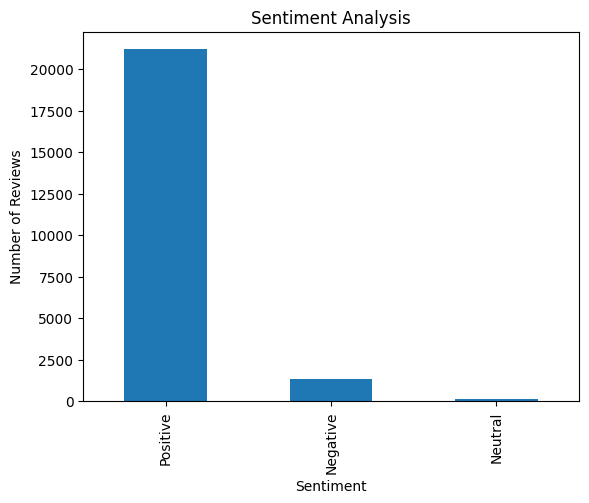

In [9]:
sentiment.plot(kind="bar")

plt.title("Sentiment Analysis")

plt.xlabel("Sentiment")

plt.ylabel("Number of Reviews")

plt.show()

In [10]:
cv = CountVectorizer(stop_words="english",max_features=10)

X = cv.fit_transform(df["Clean_Review"])

words = cv.get_feature_names_out()

count = X.toarray().sum(axis=0)

topic = pd.DataFrame({"Word":words,"Count":count})

topic = topic.sort_values(by="Count",ascending=False)

topic

,Word,Count
0,dress,10429
7,love,8884
8,size,8660
2,fit,7195
6,like,6985
9,wear,6407
3,great,6053
4,im,5925
5,just,5560
1,fabric,4732


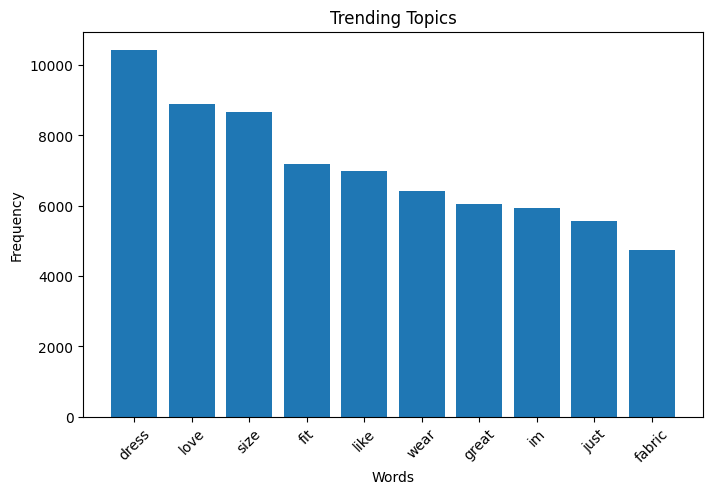

In [11]:
plt.figure(figsize=(8,5))

plt.bar(topic["Word"],topic["Count"])

plt.title("Trending Topics")

plt.xlabel("Words")

plt.ylabel("Frequency")

plt.xticks(rotation=45)

plt.show()

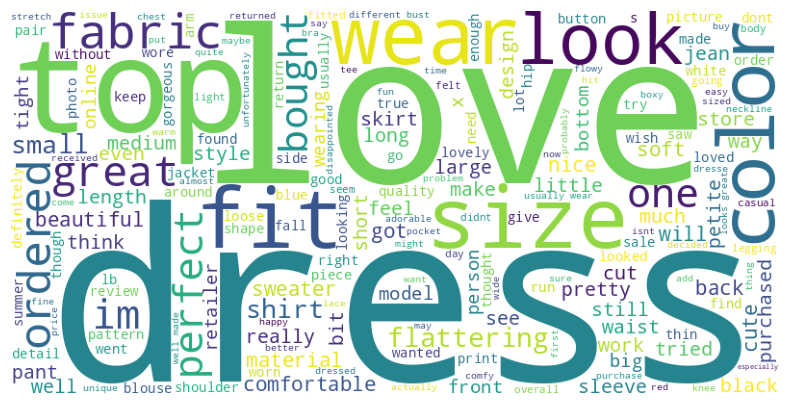

In [12]:
text = " ".join(df["Clean_Review"])

wc = WordCloud(width=800,height=400,background_color="white").generate(text)

plt.figure(figsize=(10,5))

plt.imshow(wc)

plt.axis("off")

plt.show()